# Import Libraries

In [267]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning libaries
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Data Cleaning

In [268]:
school_performance_df=pd.read_csv("../datasets/Student_Performance.csv")
school_performance_df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [269]:
school_performance_df['Pages Read']=np.linspace(0, 200, len(school_performance_df)) # per week
school_performance_df['Number of Pets']=np.random.randint(0,2,size=len(school_performance_df))
school_performance_df['Writing Utensil']=np.random.choice(['Pencil','Black Pen','Blue Pen'], size=len(school_performance_df))
school_performance_df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Pages Read,Number of Pets,Writing Utensil
0,7,99,Yes,9,1,91.0,0.000000,1,Blue Pen
1,4,82,No,4,2,65.0,0.020002,1,Black Pen
2,8,51,Yes,7,2,45.0,0.040004,0,Black Pen
3,5,52,Yes,5,2,36.0,0.060006,1,Blue Pen
4,7,75,No,8,5,66.0,0.080008,1,Blue Pen


# Useful Functions

In [270]:
# this function lets us plot categorical variables ex. sleep hours in a box plot to see the range of their distributions

def plot_one_cat_var(x,y,x_label,y_label,title):
    sns.boxplot(x=x,y=y)
    plt.title(f"Boxplot of {title}")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

In [271]:
# this function lets us plot independent vs dependent variables in a scatter plot

def plot_scatter(x,y,x_label,y_label,title):
    plt.scatter(x,y)
    plt.title(f"Scatter Plot of {title}")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

# Question 1

Does the hours studied affect a student affect academic performance?

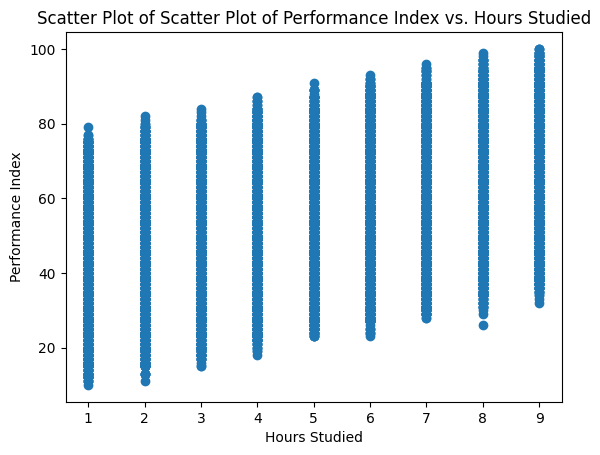

In [272]:
# Let's look at the data first and see if it follows a linear pattern

plot_scatter(school_performance_df['Hours Studied'],school_performance_df['Performance Index'],'Hours Studied','Performance Index','Scatter Plot of Performance Index vs. Hours Studied')

In [273]:
# isolate dataset for hours studied vs. grades

df = school_performance_df[['Hours Studied','Performance Index']]
df.isnull()

df = df.sample(n=2000,random_state=42)


In [274]:
X = df[['Hours Studied']]
y = df['Performance Index']


# TODO : Split data into training and test, leave X/y/test_size blank
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

In [275]:
# TODO : Create linear regression model
model=LinearRegression()

# TODO : Fit model on training data
model.fit(X_train,y_train)

# TODO : Predict on test data
y_pred = model.predict(X_test)

# TODO : Check model score
score = model.score(X_test,y_test)
print("R^2 Score: ",score)

# R^2 score shows that the model is underfitting because it can't capture the data's patterns, adding more data features should improve the model

R^2 Score:  0.16766873459695664


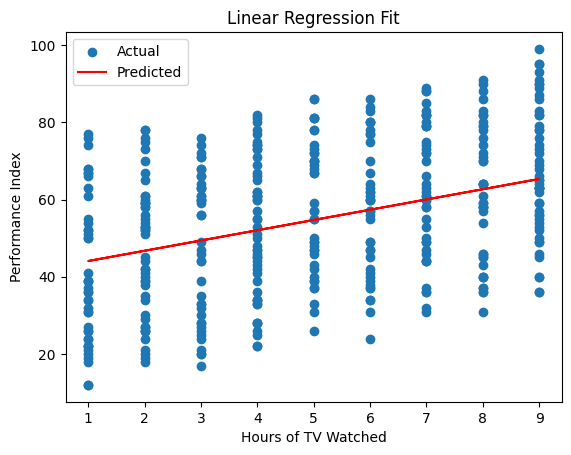

In [276]:
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color='red', label="Predicted")
plt.xlabel("Hours of TV Watched")
plt.ylabel("Performance Index")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

# Question 2

Can using all the features together help us predict student performance?

In [277]:
# isolate dataset for hours studied vs. grades

df = school_performance_df

# df = df.sample(n=2000,random_state=42)
df.columns


Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index',
       'Pages Read', 'Number of Pets', 'Writing Utensil'],
      dtype='str')

In [278]:
df = pd.get_dummies(df, columns=['Extracurricular Activities','Writing Utensil'], prefix=['Extracurricular Activities','Writing Utensil'], dtype=int)

In [279]:
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']


# TODO : Split data into training and test, leave X/y/test_size blank
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

In [ ]:
# TODO : Create linear regression model
model=LinearRegression()

# TODO : Fit model on training data
model.fit(X_train,y_train)

# TODO : Predict on test data
y_pred = model.predict(X_test)

# TODO : Check model score
score = model.score(X_test,y_test)
print("R^2 Score: ",score)

R^2 Score:  0.988979248641591


In [281]:
for col in X_train.columns:
    X_col_train = X_train[[col]]  # keep as DataFrame
    X_col_test = X_test[[col]]
    
    model = LinearRegression()
    model.fit(X_col_train, y_train)
    
    y_pred_col = model.predict(X_col_test)
    r2 = model.score(X_col_test, y_test)
    
    print(f"R^2 score for feature '{col}': {r2:.3f}")

R^2 score for feature 'Hours Studied': 0.132
R^2 score for feature 'Previous Scores': 0.841
R^2 score for feature 'Sleep Hours': 0.003
R^2 score for feature 'Sample Question Papers Practiced': 0.001
R^2 score for feature 'Pages Read': -0.001
R^2 score for feature 'Number of Pets': -0.001
R^2 score for feature 'Extracurricular Activities_No': 0.001
R^2 score for feature 'Extracurricular Activities_Yes': 0.001
R^2 score for feature 'Writing Utensil_Black Pen': -0.001
R^2 score for feature 'Writing Utensil_Blue Pen': -0.001
R^2 score for feature 'Writing Utensil_Pencil': -0.001


Model seems perfect with high R^2 score, but many features are useless

# Question 3

So is previous scores all that is needed to predict test scores?